# Лабораторная работа #4
#### Дисциплина: _"Методы Оптимизации"_ ####


#### Выполнили: __Сафин Максим Владиславович__ (P3222) | __Фокин Владимир Сергеевич__ (P3223) ####

## Задание 1. Апроксимация функции двух переменных методом Гауссианы


Данные
Мои данные:
  Точка 0: x=0.89, y=0.97, z=0.41
  Точка 1: x=2.04, y=1.83, z=1.79
  Точка 2: x=2.82, y=3.05, z=4.28
  Точка 3: x=3.84, y=3.85, z=2.54
  Точка 4: x=4.97, y=4.85, z=0.50
Значения для инициализации модельных параметров (начальное приближение):
  Amplitude (A):     4.38
  Center (x0, y0):   (2.82, 3.05)
  Sigma_x:           0.71
  Sigma_y:           0.69
  Theta (rotation):  0.00 рад
  Offset:            0.00


Запускаем оптимизацию...

РЕЗУЛЬТАТЫ

A = 4.0144
x0 = 2.9798, y0 = 3.0440
sigma_x = 1.0896, sigma_y = 1.0860
theta = -0.0096 рад = -0.55°, offset = 0.3085

Финальная ошибка: 0.00000048

Проверка модели

Проверка:
Точка 0: z=0.41000, предсказание модели=0.41145, невязка=-0.00145
Точка 1: z=1.79000, предсказание модели=1.78991, невязка=0.00009
Точка 2: z=4.28000, предсказание модели=4.27985, невязка=0.00015
Точка 3: z=2.54000, предсказание модели=2.54037, невязка=-0.00037
Точка 4: z=0.50000, предсказание модели=0.49841, невязка=0.00159

Итоговая MSE = 0.000001

✅

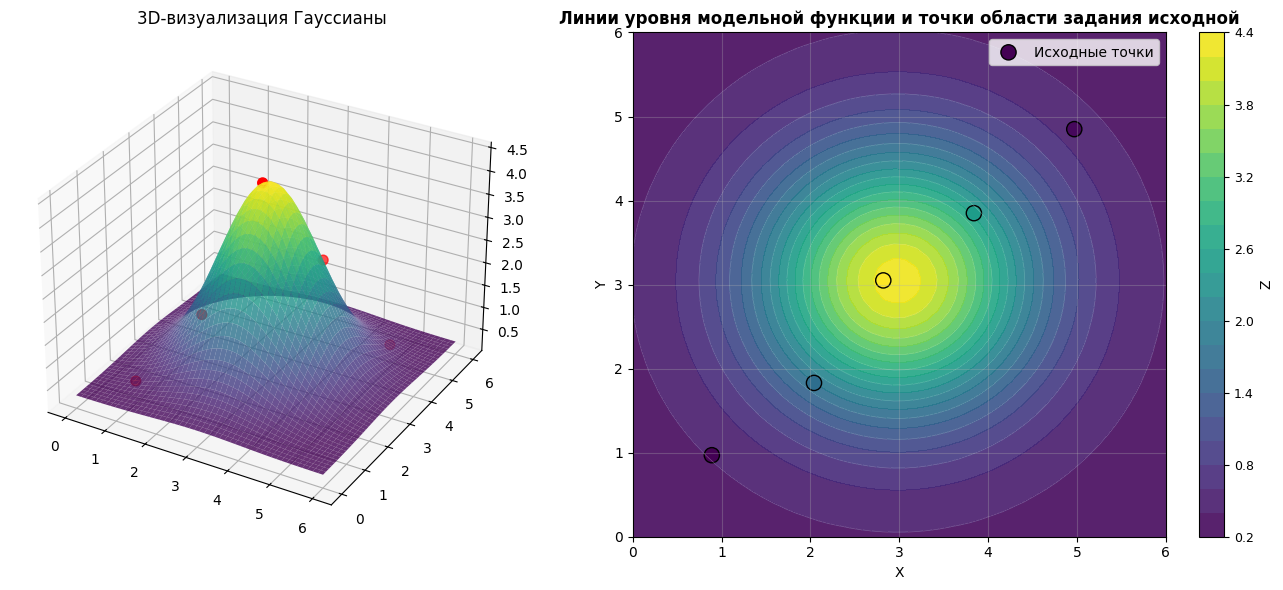

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ==============================================================================
# Вариант 1
# ==============================================================================
data = np.array([
    [0.89, 0.97, 0.41],
    [2.04, 1.83, 1.79],
    [2.82, 3.05, 4.28],
    [3.84, 3.85, 2.54],
    [4.97, 4.85, 0.50]
])

# ==============================================================================
# ЗАДАНИЕ 1: Извлеките значения из data
# ==============================================================================
X = data[:, 0]  # первый столбец - признак X
Y = data[:, 1]  # второй столбец - признак Y
Z = data[:, 2]  # третий столбец - целевая переменная Z

print("\n" + "=" * 60)
print("Данные")
print("=" * 60)
print("Мои данные:")
for i in range(len(X)):
    print(f"  Точка {i}: x={X[i]:.2f}, y={Y[i]:.2f}, z={Z[i]:.2f}")


# ==============================================================================
# ЗАДАНИЕ 2: Функция Гаусса
# ==============================================================================
def gauss_2d(x, y, A, x0, y0, sigma_x, sigma_y, theta=0, offset=0):
    """
    2D функция Гаусса
    Формула: A * exp(-(x_new^2/(2*sigma_x^2) + y_new^2/(2*sigma_y^2))) + offset,
    x_new, y_new - координаты в канонической системе (получена из исходной сдвигом и поворотом,
    используя параметры x0, y0, theta)
    """
    if theta != 0:
        x_new = (x - x0) * np.cos(theta) + (y - y0) * np.sin(theta)
        y_new = -(x - x0) * np.sin(theta) + (y - y0) * np.cos(theta)
    else:
        x_new = x - x0
        y_new = y - y0
    exp_part = np.exp(-(x_new ** 2 / (2 * sigma_x ** 2) + y_new ** 2 / (2 * sigma_y ** 2)))
    result = A * exp_part + offset

    return result


# ==============================================================================
# ЗАДАНИЕ 3: Функция потерь (loss-функция, функция ошибки)
# ==============================================================================
def loss_function(model_params):
    """
    Вычисляем MSE для реальных и модельных значений на объектах.
    """
    A, x0, y0, sigma_x, sigma_y, theta, offset = model_params

    if sigma_x <= 0 or sigma_y <= 0 or A <= 0:
        return 1e10

    predictions = []
    for i in range(len(X)):
        pred = gauss_2d(X[i], Y[i], A, x0, y0, sigma_x, sigma_y, theta, offset)
        predictions.append(pred)

    errors = Z - predictions
    mse = 0.5 * np.mean(errors ** 2)
    return mse


# ==============================================================================
# ЗАДАНИЕ 4: Начальное приближение
# ==============================================================================
max_idx = np.argmax(Z)  # индекс, соотв. максимуму Z
A_start = Z[max_idx] + 0.1  # значение максимума Z с произвольной корректировкой
x0_start = X[max_idx]  # значение Х, соотв. max_idx
y0_start = Y[max_idx]  # значение Y, соотв. max_idx
sigma_x_start = np.std(X) * 0.5
sigma_y_start = np.std(Y) * 0.5
offset_start = 0.0
theta_start = 0.0

params_start = [A_start, x0_start, y0_start, sigma_x_start, sigma_y_start, theta_start, offset_start]

print(f"Значения для инициализации модельных параметров (начальное приближение):")
print(f"  Amplitude (A):     {A_start:.2f}")
print(f"  Center (x0, y0):   ({x0_start:.2f}, {y0_start:.2f})")
print(f"  Sigma_x:           {sigma_x_start:.2f}")
print(f"  Sigma_y:           {sigma_y_start:.2f}")
print(f"  Theta (rotation):  0.00 рад")
print(f"  Offset:            0.00")
print()

# ==============================================================================
# ЗАДАНИЕ 5: Границы и оптимизация (не менять)
# ==============================================================================
bounds = [
    (0.1, 10.0), (0.0, 6.0), (0.0, 6.0),
    (0.1, 5.0), (0.1, 5.0), (-np.pi / 4, np.pi / 4), (-1.0, 1.0)
]

print("\nЗапускаем оптимизацию...")
result = minimize(loss_function, params_start, method='L-BFGS-B', bounds=bounds)

# ==============================================================================
# РЕЗУЛЬТАТЫ
# ==============================================================================
A_opt, x0_opt, y0_opt, sigma_x_opt, sigma_y_opt, theta_opt, offset_opt = result.x

print("\n" + "=" * 50)
print("РЕЗУЛЬТАТЫ")
print("=" * 50)
print(f"\nA = {A_opt:.4f}")
print(f"x0 = {x0_opt:.4f}, y0 = {y0_opt:.4f}")
print(f"sigma_x = {sigma_x_opt:.4f}, sigma_y = {sigma_y_opt:.4f}")
print(f"theta = {theta_opt:.4f} рад = {np.degrees(theta_opt):.2f}°, offset = {offset_opt:.4f}")
print(f"\nФинальная ошибка: {result.fun:.8f}")

# ==============================================================================
# ЗАДАНИЕ 6: Проверка
# ==============================================================================
predictions = []
for i in range(len(X)):
    pred = gauss_2d(X[i], Y[i], A_opt, x0_opt, y0_opt, sigma_x_opt, sigma_y_opt, theta_opt, offset_opt)
    predictions.append(pred)

print("\n" + "=" * 60)
print("Проверка модели")
print("=" * 60)
print("\nПроверка:")

for i in range(len(X)):
    print(f"Точка {i}: z={Z[i]:.5f}, предсказание модели={predictions[i]:.5f}, невязка={Z[i] - predictions[i]:.5f}")

# Вычисление итоговой MSE
final_mse = np.mean((Z - predictions) ** 2)
print(f"\nИтоговая MSE = {final_mse:.6f}")

# ==============================================================================
# ЗАДАНИЕ 7: Визуализация
# ==============================================================================
x_grid = np.linspace(0, 6, 50)
y_grid = np.linspace(0, 6, 50)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

Z_grid = np.zeros((50, 50))
for i in range(50):
    for j in range(50):
        Z_grid[i, j] = gauss_2d(X_grid[i, j], Y_grid[i, j], A_opt, x0_opt, y0_opt, sigma_x_opt, sigma_y_opt, theta_opt,
                                offset_opt)

# Графики
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X_grid, Y_grid, Z_grid, cmap='viridis', alpha=0.8)
ax1.scatter(X, Y, Z, c='red', s=50)
ax1.set_title('3D-визуализация Гауссианы')

ax2 = fig.add_subplot(122)
contour = ax2.contourf(X_grid, Y_grid, Z_grid, levels=25, cmap='viridis', alpha=0.9)
scatter = ax2.scatter(X, Y, c=Z, s=120, edgecolors='black', cmap='viridis', label='Исходные точки')
ax2.contour(X_grid, Y_grid, Z_grid, levels=10, colors='white', alpha=0.3, linewidths=0.5)
ax2.set_xlabel('X', fontsize=10)
ax2.set_ylabel('Y', fontsize=10)
ax2.set_title('Линии уровня модельной функции и точки области задания исходной', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()
cbar = plt.colorbar(contour, ax=ax2, label='Z')
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
print("\n✅ Готово! Получилась двумерная гауссиана - аппроксимация для z(x,y)!")
plt.show()


## Задание 2. Апроксимация функции двух переменных методом эллиптического парабалоида


ЗАДАНИЕ 2: Аппроксимация эллиптическим параболоидом

Начальное приближение для параболоида:
  a = -0.30, b = -0.30
  x0 = 2.82, y0 = 3.05
  c = 4.28

Запускаем оптимизацию для параболоида...

РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ ПАРАБОЛОИДОМ

a = -0.233424
b = -0.556926
x0 = 0.8040, y0 = 3.8958
c = 5.000000

Финальная MSE: 0.15008804

----------------------------------------
Проверка на точках:
----------------------------------------
Точка 0: z=0.41, предсказание=0.23, невязка=0.1791
Точка 1: z=1.79, предсказание=2.27, невязка=-0.4767
Точка 2: z=4.28, предсказание=3.65, невязка=0.6271
Точка 3: z=2.54, предсказание=2.85, невязка=-0.3073
Точка 4: z=0.50, предсказание=0.44, невязка=0.0583

Средняя квадратичная ошибка (MSE): 0.15008804
Средняя абсолютная ошибка (MAE): 0.329708

Количество итераций оптимизации: 366


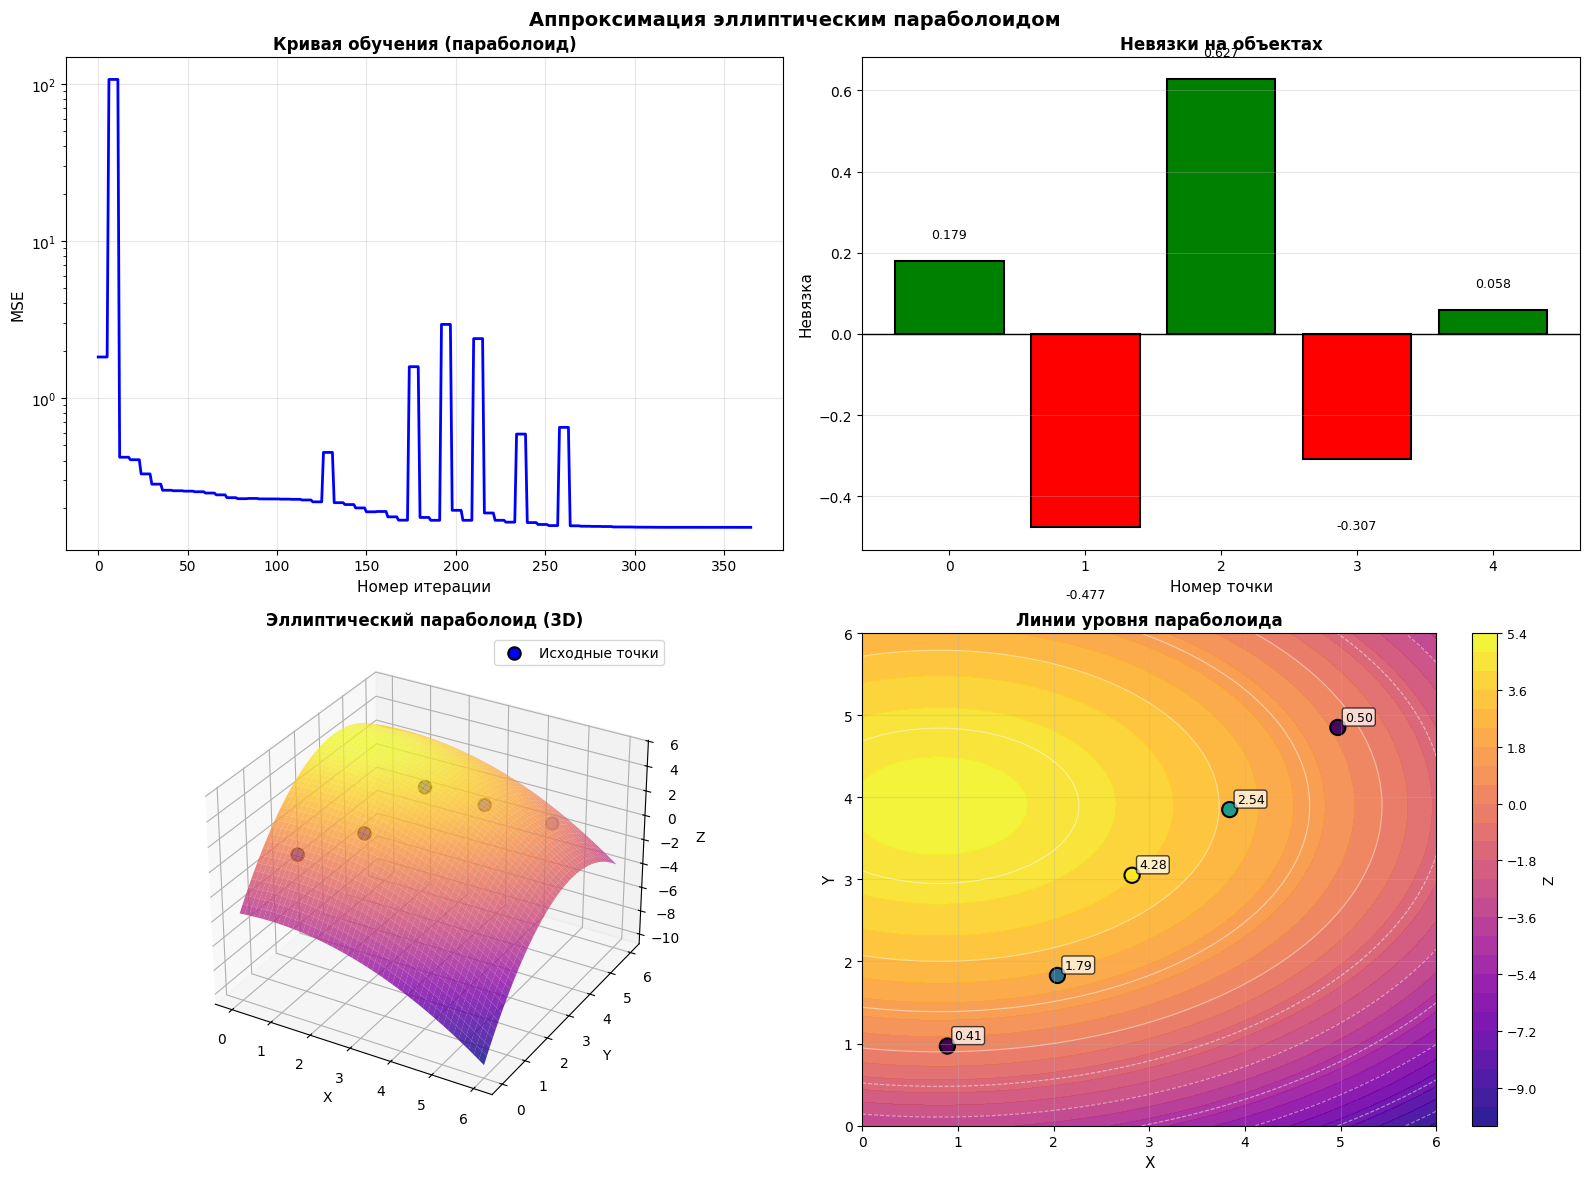


Аналитический вид полученной модели (параболоид):
z(x,y) = (-0.233424)·(x - 0.8040)² + (-0.556926)·(y - 3.8958)² + 5.000000

где a и b отрицательные, поэтому параболоид имеет форму 'шапки' (максимум в центре)


In [8]:
# ==============================================================================
# ЗАДАНИЕ 2: Аппроксимация эллиптическим параболоидом
# ИСПРАВЛЕННАЯ ВЕРСИЯ
# ==============================================================================

print("\n" + "="*60)
print("ЗАДАНИЕ 2: Аппроксимация эллиптическим параболоидом")
print("="*60)

def paraboloid_2d(x, y, a, b, x0, y0, c):
    """
    2D эллиптический параболоид
    Формула: z = a*(x-x0)² + b*(y-y0)² + c
    """
    return a * (x - x0)**2 + b * (y - y0)**2 + c

def loss_function_paraboloid(params):
    """MSE для эллиптического параболоида"""
    a, b, x0, y0, c = params

    # Для формы "шапки" (максимум в центре) a и b должны быть отрицательными
    if a >= 0 or b >= 0:
        return 1e10  # Штрафуем положительные значения

    predictions = paraboloid_2d(X, Y, a, b, x0, y0, c)
    mse = np.mean((Z - predictions)**2)
    return mse

# Начальное приближение
max_idx = np.argmax(Z)
a_start = -0.3
b_start = -0.3
x0_start = X[max_idx]
y0_start = Y[max_idx]
c_start = Z[max_idx]

params_start_par = [a_start, b_start, x0_start, y0_start, c_start]

print(f"\nНачальное приближение для параболоида:")
print(f"  a = {a_start:.2f}, b = {b_start:.2f}")
print(f"  x0 = {x0_start:.2f}, y0 = {y0_start:.2f}")
print(f"  c = {c_start:.2f}")

# Границы для параметров
bounds_par = [
    (-2.0, -0.01),   # a (отрицательный)
    (-2.0, -0.01),   # b (отрицательный)
    (0.0, 6.0),      # x0
    (0.0, 6.0),      # y0
    (-1.0, 5.0)      # c
]

print("\nЗапускаем оптимизацию для параболоида...")
result_par = minimize(loss_function_paraboloid, params_start_par, method='L-BFGS-B', bounds=bounds_par)

# Получение результатов
a_opt, b_opt, x0_opt_par, y0_opt_par, c_opt = result_par.x

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ ПАРАБОЛОИДОМ")
print("="*60)
print(f"\na = {a_opt:.6f}")
print(f"b = {b_opt:.6f}")
print(f"x0 = {x0_opt_par:.4f}, y0 = {y0_opt_par:.4f}")
print(f"c = {c_opt:.6f}")
print(f"\nФинальная MSE: {result_par.fun:.8f}")

# Предсказания и невязки
predictions_par = paraboloid_2d(X, Y, a_opt, b_opt, x0_opt_par, y0_opt_par, c_opt)
residuals_par = Z - predictions_par

print("\n" + "-"*40)
print("Проверка на точках:")
print("-"*40)
for i in range(len(X)):
    print(f"Точка {i}: z={Z[i]:.2f}, предсказание={predictions_par[i]:.2f}, невязка={residuals_par[i]:.4f}")

print(f"\nСредняя квадратичная ошибка (MSE): {np.mean(residuals_par**2):.8f}")
print(f"Средняя абсолютная ошибка (MAE): {np.mean(np.abs(residuals_par)):.6f}")

# ==============================================================================
# Кривая обучения (лосс как функция от номера итерации)
# ==============================================================================

# Перезапускаем оптимизацию с записью истории
history_par = []
def loss_with_history(params):
    loss = loss_function_paraboloid(params)
    history_par.append(loss)
    return loss

result_with_history = minimize(loss_with_history, params_start_par, method='L-BFGS-B',
                                bounds=bounds_par, options={'maxiter': 100})

print(f"\nКоличество итераций оптимизации: {len(history_par)}")

# ==============================================================================
# Визуализация (ИСПРАВЛЕННАЯ)
# ==============================================================================

# Создаем сетку для визуализации
x_grid = np.linspace(0, 6, 50)
y_grid = np.linspace(0, 6, 50)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
Z_grid_par = paraboloid_2d(X_grid, Y_grid, a_opt, b_opt, x0_opt_par, y0_opt_par, c_opt)

# Создаем фигуру с 4 подграфиками
fig = plt.figure(figsize=(16, 12))

# 1. Кривая обучения
ax1 = fig.add_subplot(221)
ax1.plot(history_par, 'b-', linewidth=2)
ax1.set_xlabel('Номер итерации', fontsize=11)
ax1.set_ylabel('MSE', fontsize=11)
ax1.set_title('Кривая обучения (параболоид)', fontsize=12, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# 2. Гистограмма невязок (ИСПРАВЛЕНО: edgecolor вместо edgecolors)
ax2 = fig.add_subplot(222)
colors = ['red' if r < 0 else 'green' for r in residuals_par]
bars = ax2.bar(range(len(residuals_par)), residuals_par, color=colors, edgecolor='black', linewidth=1.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Номер точки', fontsize=11)
ax2.set_ylabel('Невязка', fontsize=11)
ax2.set_title('Невязки на объектах', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
# Добавляем значения на столбцы
for i, (bar, res) in enumerate(zip(bars, residuals_par)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.05 if res >= 0 else -0.15),
             f'{res:.3f}', ha='center', va='bottom' if res >= 0 else 'top', fontsize=9)

# 3. 3D поверхность параболоида
ax3 = fig.add_subplot(223, projection='3d')
surf = ax3.plot_surface(X_grid, Y_grid, Z_grid_par, cmap='plasma', alpha=0.8, edgecolor='none')
ax3.scatter(X, Y, Z, c='blue', s=80, edgecolors='black', linewidth=1.5, label='Исходные точки')
ax3.set_xlabel('X', fontsize=10)
ax3.set_ylabel('Y', fontsize=10)
ax3.set_zlabel('Z', fontsize=10)
ax3.set_title('Эллиптический параболоид (3D)', fontsize=12, fontweight='bold')
ax3.legend()

# 4. Линии уровня
ax4 = fig.add_subplot(224)
contour = ax4.contourf(X_grid, Y_grid, Z_grid_par, levels=25, cmap='plasma', alpha=0.9)
ax4.scatter(X, Y, c=Z, s=120, edgecolors='black', linewidth=1.5)
ax4.contour(X_grid, Y_grid, Z_grid_par, levels=10, colors='white', alpha=0.5, linewidths=0.8)
# Добавляем подписи значений Z
for i, (x, y, z) in enumerate(zip(X, Y, Z)):
    ax4.annotate(f'{z:.2f}', (x, y), xytext=(5, 5), textcoords='offset points', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
ax4.set_xlabel('X', fontsize=11)
ax4.set_ylabel('Y', fontsize=11)
ax4.set_title('Линии уровня параболоида', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
cbar = plt.colorbar(contour, ax=ax4, label='Z')
cbar.ax.tick_params(labelsize=9)

plt.suptitle('Аппроксимация эллиптическим параболоидом', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Аналитический вид полученной модели (параболоид):")
print("="*60)
print(f"z(x,y) = ({a_opt:.6f})·(x - {x0_opt_par:.4f})² + ({b_opt:.6f})·(y - {y0_opt_par:.4f})² + {c_opt:.6f}")
print("\nгде a и b отрицательные, поэтому параболоид имеет форму 'шапки' (максимум в центре)")

## Задание 3. Нахождение наилучшей апроксимации


ЗАДАНИЕ 3: Константная модель

Исходные данные (Z):
  Точка 0: z = 0.41
  Точка 1: z = 1.79
  Точка 2: z = 4.28
  Точка 3: z = 2.54
  Точка 4: z = 0.50

----------------------------------------
1. Минимизация MSE
----------------------------------------

Оптимальная константа (среднее арифметическое): c_MSE = 1.9040
Значение MSE: 2.053224

Невязки (ошибки) на каждой точке:
  Точка 0: 0.41 - 1.9040 = -1.4940
  Точка 1: 1.79 - 1.9040 = -0.1140
  Точка 2: 4.28 - 1.9040 = 2.3760
  Точка 3: 2.54 - 1.9040 = 0.6360
  Точка 4: 0.50 - 1.9040 = -1.4040

----------------------------------------
2. Минимизация MAE
----------------------------------------

Оптимальная константа (медиана): c_MAE = 1.7900
Значение MAE: 1.182000

Невязки (ошибки) на каждой точке:
  Точка 0: 0.41 - 1.7900 = -1.3800
  Точка 1: 1.79 - 1.7900 = 0.0000
  Точка 2: 4.28 - 1.7900 = 2.4900
  Точка 3: 2.54 - 1.7900 = 0.7500
  Точка 4: 0.50 - 1.7900 = -1.2900

----------------------------------------
3. Сравнение моделей
------

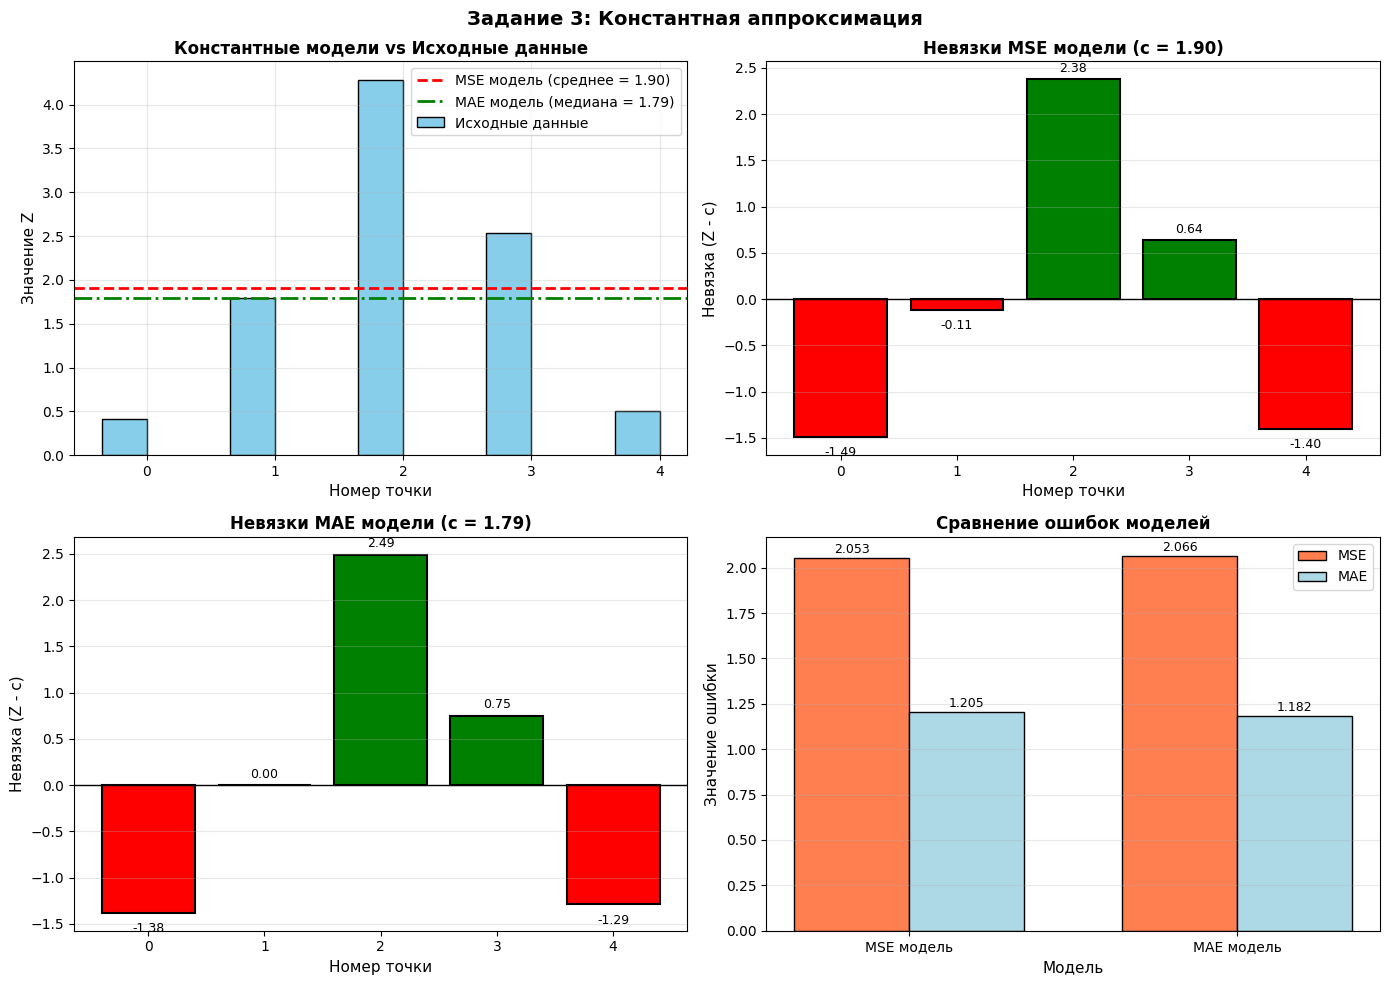

In [11]:
# ==============================================================================
# ЗАДАНИЕ 3: Константная модель
# ==============================================================================

print("\n" + "="*60)
print("ЗАДАНИЕ 3: Константная модель")
print("="*60)

# Исходные данные
print("\nИсходные данные (Z):")
for i, z in enumerate(Z):
    print(f"  Точка {i}: z = {z:.2f}")

# ==============================================================================
# 1. Минимизация MSE (Mean Squared Error)
# ==============================================================================

print("\n" + "-"*40)
print("1. Минимизация MSE")
print("-"*40)

# Теоретически: оптимальная константа для MSE = среднее арифметическое
const_mse = np.mean(Z)
print(f"\nОптимальная константа (среднее арифметическое): c_MSE = {const_mse:.4f}")

# Вычисляем MSE для этой константы
predictions_mse = np.full_like(Z, const_mse)
mse_value = np.mean((Z - predictions_mse)**2)
print(f"Значение MSE: {mse_value:.6f}")

# Невязки для MSE модели
residuals_mse = Z - const_mse
print("\nНевязки (ошибки) на каждой точке:")
for i, res in enumerate(residuals_mse):
    print(f"  Точка {i}: {Z[i]:.2f} - {const_mse:.4f} = {res:.4f}")

# ==============================================================================
# 2. Минимизация MAE (Mean Absolute Error)
# ==============================================================================

print("\n" + "-"*40)
print("2. Минимизация MAE")
print("-"*40)

# Теоретически: оптимальная константа для MAE = медиана
const_mae = np.median(Z)
print(f"\nОптимальная константа (медиана): c_MAE = {const_mae:.4f}")

# Вычисляем MAE для этой константы
predictions_mae = np.full_like(Z, const_mae)
mae_value = np.mean(np.abs(Z - predictions_mae))
print(f"Значение MAE: {mae_value:.6f}")

# Невязки для MAE модели
residuals_mae = Z - const_mae
print("\nНевязки (ошибки) на каждой точке:")
for i, res in enumerate(residuals_mae):
    print(f"  Точка {i}: {Z[i]:.2f} - {const_mae:.4f} = {res:.4f}")

# ==============================================================================
# 3. Сравнение моделей
# ==============================================================================

print("\n" + "-"*40)
print("3. Сравнение моделей")
print("-"*40)

# MSE для MAE-модели
mse_of_mae_model = np.mean((Z - const_mae)**2)
print(f"\nMSE-модель (c = {const_mse:.4f}):")
print(f"  MSE = {mse_value:.6f}")
print(f"  MAE = {np.mean(np.abs(residuals_mse)):.6f}")

print(f"\nMAE-модель (c = {const_mae:.4f}):")
print(f"  MSE = {mse_of_mae_model:.6f}")
print(f"  MAE = {mae_value:.6f}")

# Какая модель лучше по каждому критерию?
print(f"\nВыводы:")
if mse_value < mse_of_mae_model:
    print(f"  ✅ По критерию MSE лучше модель с константой = среднему ({const_mse:.4f})")
else:
    print(f"  ✅ По критерию MSE лучше модель с константой = медиане ({const_mae:.4f})")

if mae_value < np.mean(np.abs(residuals_mse)):
    print(f"  ✅ По критерию MAE лучше модель с константой = медиане ({const_mae:.4f})")
else:
    print(f"  ✅ По критерию MAE лучше модель с константой = среднему ({const_mse:.4f})")

# ==============================================================================
# 4. Визуализация
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Точки и константные модели
ax1 = axes[0, 0]
x_pos = np.arange(len(Z))
width = 0.35

ax1.bar(x_pos - width/2, Z, width, label='Исходные данные', color='skyblue', edgecolor='black')
ax1.axhline(y=const_mse, color='red', linestyle='--', linewidth=2, label=f'MSE модель (среднее = {const_mse:.2f})')
ax1.axhline(y=const_mae, color='green', linestyle='-.', linewidth=2, label=f'MAE модель (медиана = {const_mae:.2f})')

ax1.set_xlabel('Номер точки', fontsize=11)
ax1.set_ylabel('Значение Z', fontsize=11)
ax1.set_title('Константные модели vs Исходные данные', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Невязки для MSE модели
ax2 = axes[0, 1]
colors_mse = ['red' if r < 0 else 'green' for r in residuals_mse]
bars_mse = ax2.bar(x_pos, residuals_mse, color=colors_mse, edgecolor='black', linewidth=1.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Номер точки', fontsize=11)
ax2.set_ylabel('Невязка (Z - c)', fontsize=11)
ax2.set_title(f'Невязки MSE модели (c = {const_mse:.2f})', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for i, (bar, res) in enumerate(zip(bars_mse, residuals_mse)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.05 if res >= 0 else -0.1),
             f'{res:.2f}', ha='center', va='bottom' if res >= 0 else 'top', fontsize=9)

# График 3: Невязки для MAE модели
ax3 = axes[1, 0]
colors_mae = ['red' if r < 0 else 'green' for r in residuals_mae]
bars_mae = ax3.bar(x_pos, residuals_mae, color=colors_mae, edgecolor='black', linewidth=1.5)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax3.set_xlabel('Номер точки', fontsize=11)
ax3.set_ylabel('Невязка (Z - c)', fontsize=11)
ax3.set_title(f'Невязки MAE модели (c = {const_mae:.2f})', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
for i, (bar, res) in enumerate(zip(bars_mae, residuals_mae)):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.05 if res >= 0 else -0.1),
             f'{res:.2f}', ha='center', va='bottom' if res >= 0 else 'top', fontsize=9)

# График 4: Сравнение ошибок
ax4 = axes[1, 1]
models = ['MSE модель', 'MAE модель']
mse_errors = [mse_value, mse_of_mae_model]
mae_errors = [np.mean(np.abs(residuals_mse)), mae_value]

x_pos_comp = np.arange(len(models))
width_comp = 0.35

ax4.bar(x_pos_comp - width_comp/2, mse_errors, width_comp, label='MSE', color='coral', edgecolor='black')
ax4.bar(x_pos_comp + width_comp/2, mae_errors, width_comp, label='MAE', color='lightblue', edgecolor='black')
ax4.set_xlabel('Модель', fontsize=11)
ax4.set_ylabel('Значение ошибки', fontsize=11)
ax4.set_title('Сравнение ошибок моделей', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos_comp)
ax4.set_xticklabels(models)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, (mse, mae) in enumerate(zip(mse_errors, mae_errors)):
    ax4.text(i - width_comp/2, mse + 0.01, f'{mse:.3f}', ha='center', va='bottom', fontsize=9)
    ax4.text(i + width_comp/2, mae + 0.01, f'{mae:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Задание 3: Константная аппроксимация', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()